### 4.1 Preparação

Usamos os índices inteiros de −5 a 20, incluindo a origem e amostras anteriores à ativação dos sinais causais. As amplitudes são adimensionais. As hastes indicam as amostras; não há interpolação entre elas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(-5, 21)
plt.rcParams.update({"figure.figsize": (10, 3.5), "font.size": 11})

def representar(ax, valores, titulo):
    ax.stem(n, valores, basefmt="k-")
    ax.set(title=titulo, xlabel="Índice n", ylabel="Amplitude")
    ax.set_xticks(np.arange(-5, 21, 5))
    ax.grid(True, alpha=0.3)


### 4.2 Impulso unitário

**Expressão:**

$$x[n]=\delta[n]=\begin{cases}1,&n=0,\\0,&n\neq0.\end{cases}$$

**Parâmetros:** amplitude unitária, impulso sem deslocamento, localizado em $n=0$, e janela $-5\leq n\leq20$.

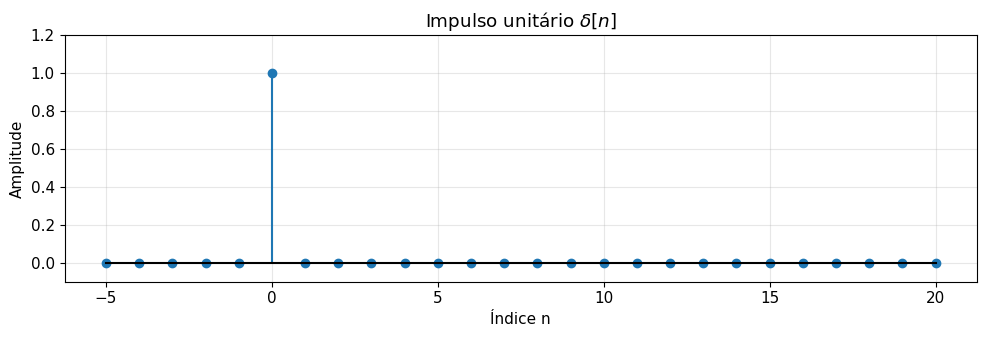

In [2]:
delta = (n == 0).astype(int)
fig, ax = plt.subplots()
representar(ax, delta, r"Impulso unitário $\delta[n]$")
ax.set_ylim(-0.1, 1.2)
plt.tight_layout()
plt.show()

**Interpretação:** somente a amostra em $n=0$ vale 1; todas as demais valem zero. Um impulso deslocado $\delta[n-k]$ seleciona a posição $n=k$. Ao multiplicá-lo por $x[k]$ e somar sobre os índices $k$, reconstruímos a sequência, como discutido na seção 2.1.

### 4.3 Degrau unitário

**Expressão:**

$$x[n]=u[n]=\begin{cases}1,&n\geq0,\\0,&n<0.\end{cases}$$

**Parâmetros:** amplitude unitária, ativação em $n=0$ e janela $-5\leq n\leq20$. O segundo gráfico verifica $\delta[n]=u[n]-u[n-1]$.

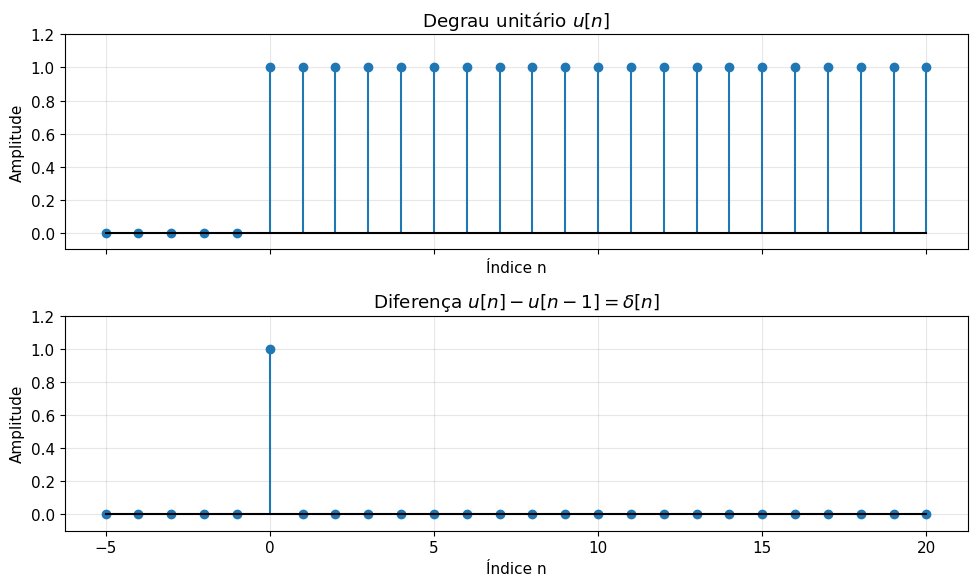

Verificação: u[n] - u[n-1] coincide com o impulso em toda a janela.


In [3]:
u = (n >= 0).astype(int)
u_deslocado = (n >= 1).astype(int)
diferenca = u - u_deslocado

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
representar(axes[0], u, r"Degrau unitário $u[n]$")
representar(axes[1], diferenca, r"Diferença $u[n]-u[n-1]=\delta[n]$")
for ax in axes:
    ax.set_ylim(-0.1, 1.2)
plt.tight_layout()
plt.show()

assert np.array_equal(diferenca, delta)
print("Verificação: u[n] - u[n-1] coincide com o impulso em toda a janela.")

**Interpretação:** o degrau permanece nulo para índices negativos e assume o valor 1 a partir da origem, incluindo $n=0$. A diferença entre o degrau e sua versão atrasada de uma amostra é não nula apenas na transição, produzindo o impulso unitário.

### 4.4 Exponencial causal

**Expressão:**

$$x_a[n]=a^nu[n]=\begin{cases}a^n,&n\geq0,\\0,&n<0.\end{cases}$$

**Parâmetros:** $a\in\{0{,}5;\ 1;\ 1{,}2;\ -0{,}5;\ -1;\ -1{,}2\}$, valor inicial $x_a[0]=1$ e janela $-5\leq n\leq20$.

Calculamos as potências apenas para $n\geq0$, pois o degrau anula as amostras anteriores à origem. Cada painel tem sua própria escala vertical para permitir observar tanto o decaimento quanto o crescimento.

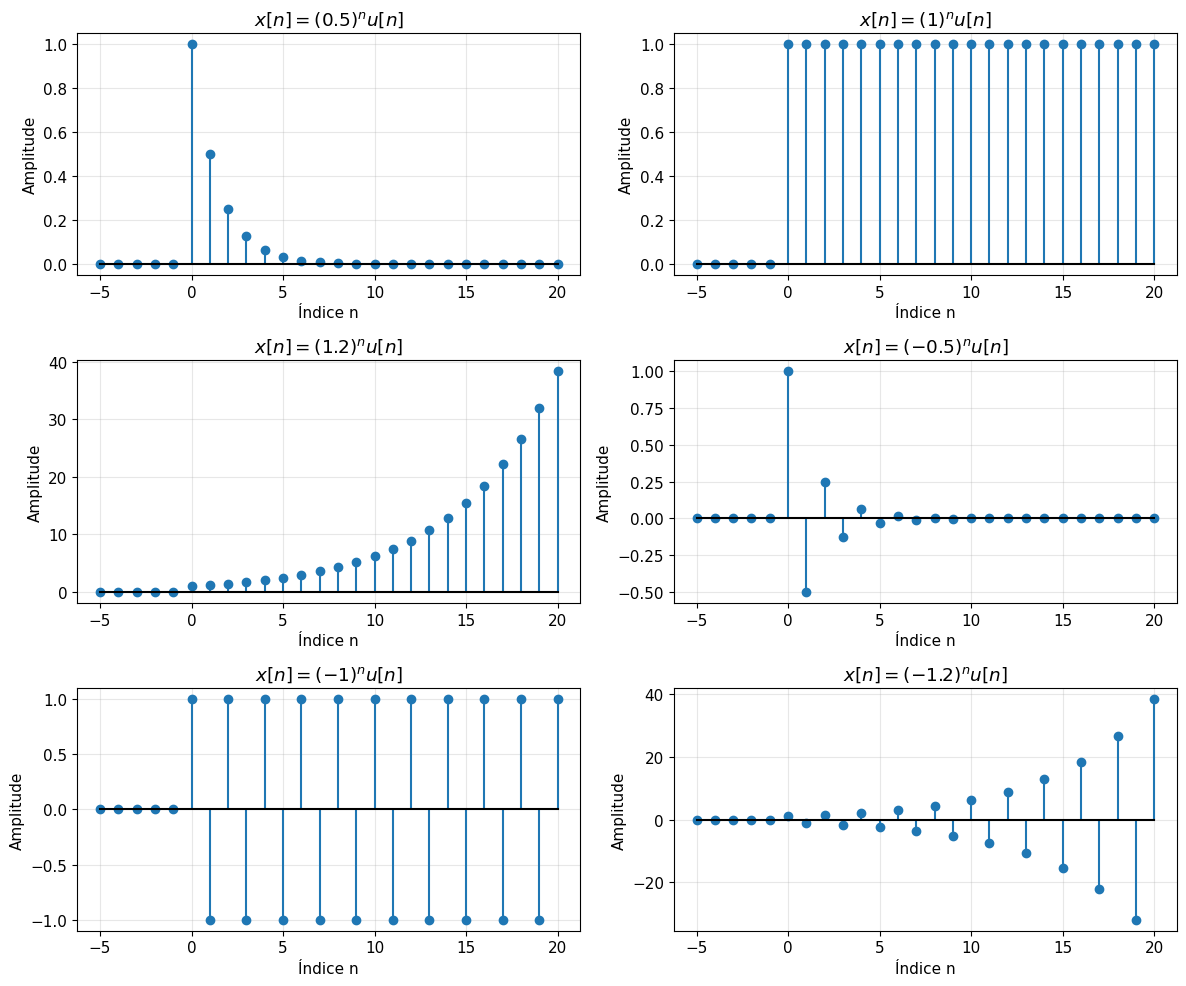

In [4]:
bases = [0.5, 1.0, 1.2, -0.5, -1.0, -1.2]
exponenciais = {}
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
causal = n >= 0

for ax, a in zip(axes.flat, bases):
    x = np.zeros(n.shape, dtype=float)
    x[causal] = a ** n[causal]
    exponenciais[a] = x
    representar(ax, x, rf"$x[n]=({a:g})^n u[n]$")

plt.tight_layout()
plt.show()

**Interpretação:** todos os casos são nulos para $n<0$ e começam em 1 na origem.

| Base $a$ | Comportamento para $n\geq0$ |
| :---: | :--- |
| $0{,}5$ | Decai positivamente em direção a zero; cada amostra é metade da anterior. |
| $1$ | Mantém o valor 1, coincidindo com o degrau unitário. |
| $1{,}2$ | Cresce positivamente; cada amostra é 20% maior que a anterior. |
| $-0{,}5$ | Alterna o sinal e decai em módulo em direção a zero. |
| $-1$ | Alterna entre 1 e −1, mantendo módulo unitário após a ativação. |
| $-1{,}2$ | Alterna o sinal e cresce em módulo. |

O módulo $|a|$ determina a evolução da magnitude, e o sinal de $a$ determina a alternância. O caso $a=-1$ tem um padrão de duas amostras na região $n\geq0$, mas a sequência causal completa não é periódica devido à região nula para $n<0$.

### 4.5 Senoide discreta

**Expressão:**

$$x[n]=2\cos\left(\frac{\pi}{4}n+\frac{\pi}{4}\right).$$

**Parâmetros:** $A=2$, $\omega_0=\pi/4$ radianos por amostra, $\phi=\pi/4$ radianos e janela $-5\leq n\leq20$. A frequência equivale a $f=\omega_0/(2\pi)=1/8$ ciclo por amostra. O período fundamental é $N_0=8$, pois $(\pi/4)N_0=2\pi$.

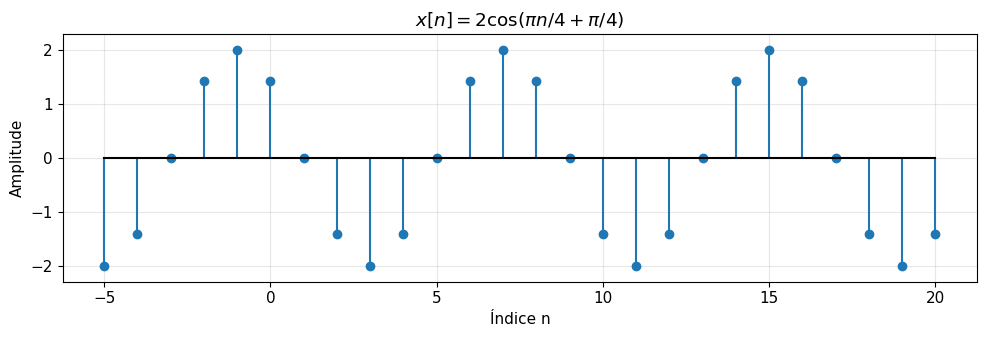

Período verificado: 8 amostras.
Valor na origem: x[0] = 1.4142.


In [5]:
A = 2.0
omega0 = np.pi / 4
phi = np.pi / 4
N0 = 8
senoide = A * np.cos(omega0 * n + phi)

fig, ax = plt.subplots()
representar(ax, senoide, r"$x[n]=2\cos(\pi n/4+\pi/4)$")
ax.set_ylim(-2.3, 2.3)
plt.tight_layout()
plt.show()

assert np.allclose(senoide[:-N0], senoide[N0:])
print(f"Período verificado: {N0} amostras.")
print(f"Valor na origem: x[0] = {senoide[n == 0][0]:.4f}.")

**Interpretação:** a sequência oscila entre −2 e 2 e repete seus valores a cada oito amostras. A fase escolhida produz $x[0]=2\cos(\pi/4)=\sqrt{2}$ e antecipa o cosseno de fase zero em uma amostra, pois $x[n]=2\cos[\pi(n+1)/4]$. Valores teoricamente nulos podem aparecer como números muito pequenos devido à precisão numérica.

Pela identidade de Euler, a mesma sequência pode ser escrita como

$$x[n]=\operatorname{Re}\left\{2e^{j(\pi n/4+\pi/4)}\right\}.$$

Assim, o gráfico também representa a parte real de uma exponencial complexa de módulo 2; sua parte imaginária é $2\sin(\pi n/4+\pi/4)$.